In [1]:
import numpy as np
import scipy.io
from sklearn import metrics
import pandas as pd
import os
import scipy.io as sio
import os.path
import time
import random
import math

import tensorflow.keras as keras
import tensorflow as tf
import matplotlib.pyplot as plt

from keras.layers import Embedding
from keras.models import Model
from keras.layers import Dense, Dropout, Activation, Flatten, Layer, merge, Input, Concatenate, Reshape
from keras.layers.convolutional import Conv1D, MaxPooling1D
from keras.layers.pooling import GlobalMaxPooling1D
from keras.layers.recurrent import LSTM
from keras.layers.wrappers import Bidirectional, TimeDistributed
from keras.models import load_model
from keras.callbacks import ModelCheckpoint, EarlyStopping
from keras import backend as K
import tensorflow.keras as keras
import tensorflow as tf
import matplotlib.pyplot as plt

In [2]:
gpu_devices = tf.config.experimental.list_physical_devices('GPU')
for device in gpu_devices:
    tf.config.experimental.set_memory_growth(device, True)

2022-02-24 13:32:06.805228: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:936] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2022-02-24 13:32:06.809187: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:936] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2022-02-24 13:32:06.809331: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:936] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero


In [39]:
# Library of Helper Functions

def readInputAsArray(fileName):
    with open(fileName, 'r') as myfile:
        data = myfile.readlines()

    # Strip newline
    for i in range(0, len(data)):
        data[i] = data[i].rstrip()
    # print(data)
    return data

def readInputAsString(fileName):
    with open(fileName, 'r') as myfile:
        data=myfile.read().replace('\n', ' ')
        # print 
    return data

def reverse_complement(seq):    
    complement = {'A': 'T', 'C': 'G', 'G': 'C', 'T': 'A'}
    reverse_complement = ''.join(complement.get(base, base) for base in reversed(seq))
    return reverse_complement

def oneHotEncode(seq):
    import numpy as np
    seq2=list()
    mapping = {"A":[1., 0., 0., 0.], "C": [0., 1., 0., 0.], "G": [0., 0., 1., 0.], "T":[0., 0., 0., 1.]};
    for i in seq:
    	seq2.append(mapping[i]  if i in mapping.keys() else [0., 0., 0., 0.]);
    return seq2;

def ReverseOneHotEncode(arr):
    seq = ''
    nuc_map = ['A', 'C', 'G', 'T']
    for subarr in arr:
        nuc = nuc_map[np.argmax(subarr)]
        seq+=nuc
    return seq;

def writeSeqToFile(d,ones,zeros):
    fname = '/Users/yibeijia/Downloads/nucleosome_occupancy/data/SeqsForFeature.txt'
    fname='/home/yibei/Projects/nucleosome_occupancy/data/SeqsForFeature.txt'
    out = 'Enriched:\n'
    for i in ones:
        seq = ReverseOneHotEncode(d[i])
        out = out + str(1) + ' ' + seq + '\n'
    out += 'Depleted:\n'
    for i in zeros:
        seq = ReverseOneHotEncode(d[i])
        out = out + str(0) + ' ' + seq + '\n'
    with open(fname, 'w+') as f:
        f.write(out)      
        
def tokenize(str):
    out = []
    for i in range(len(str)-4):
        out.append(str[i:i+5])
    return out

# Normalize an array 
def min_max_norm(arr):
    new_arr = []
    min_v = min(arr)
    max_v = max(arr)
    for num in arr:
        new_arr=new_arr+[(num-min_v)/(max_v-min_v)]
    return(new_arr)

def read_SD_table(fileName):
    tb_data = readInputAsArray(fileName)
    tb = {}
    DNAshape = tb_data[0].split("\t")
    # print(DNAshape)
    for i in range(1, len(tb_data)):
        line = tb_data[i].split("\t")
        key = line[0]
        value = line[1:]
        for j in range(0, len(value)):
            value[j] = float(value[j])
        tb[key] = value
    # print(tb)
    return(tb)

In [4]:
# Helper function to plot data colored with attention weights
class CharVal(object):
    def __init__(self, char, val):
        self.char = char
        self.val = val

    def __str__(self):
        return self.char

def rgb_to_hex(rgb):
    return '#%02x%02x%02x' % rgb

def color_charvals(s):
    r = 255-int(s.val*255)
#     r = int(s.val*255)
#     print(r)
    color = rgb_to_hex((r, r, 255))
    return 'background-color: %s' % color

# a list of 5mers, token and a list of their attention values, currseq_attention_output
def plot_attention_from_seq(token, currseq_attention_output):

    vals_normalized = min_max_norm(currseq_attention_output)
#     print(vals_normalized)
    # match each 5mer with sum of the 320 dim array attention weight array
    char_vals = [CharVal(c, v) for c, v in zip(token, vals_normalized)]
    char_df = pd.DataFrame(char_vals).transpose()
    # apply coloring values
    char_df = char_df.style.applymap(color_charvals)
    return char_df


def plot_attention_from_map(map):

    # match each 5mer with sum of the 320 dim array attention weight array
    vals_normalized = min_max_norm(map.values())
    char_vals = [CharVal(c, v) for c, v in zip(map.keys(), vals_normalized)]
    char_df = pd.DataFrame(char_vals).transpose()
    # apply coloring values
    char_df = char_df.style.applymap(color_charvals)
    return char_df

In [5]:
data_folder = "/Users/yibeijia/Downloads/nucleosome_occupancy/tbinet_stuff/model2/"

data_folder = "/Users/yibeijia/Downloads/nucleosome_occupancy/tbinet_stuff/model2_reduced_dense10/"
data_folder = "/Users/yibeijia/Downloads/nucleosome_occupancy/tbinet_stuff/model3/"
data_folder = "/Users/yibeijia/Downloads/nucleosome_occupancy/tbinet_stuff/train_dense10_kernel10_run10/"
data_folder = "/home/yibei/Projects/nucleosome_occupancy/tbinet_stuff/train_dense10_kernel10_run2/"
model = load_model(data_folder+"tbinet.h5")

model.summary()



2022-02-24 13:32:14.210896: I tensorflow/core/platform/cpu_feature_guard.cc:151] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2022-02-24 13:32:14.212444: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:936] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2022-02-24 13:32:14.212698: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:936] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2022-02-24 13:32:14.212880: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:936] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zer

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 147, 4)]     0           []                               
                                                                                                  
 conv1d (Conv1D)                (None, 147, 320)     13120       ['input_1[0][0]']                
                                                                                                  
 max_pooling1d (MaxPooling1D)   (None, 143, 320)     0           ['conv1d[0][0]']                 
                                                                                                  
 dropout (Dropout)              (None, 143, 320)     0           ['max_pooling1d[0][0]']          
                                                                                              

In [33]:
## load model with its attention weights using the "Multiply layer" 
attention_wt_model = tf.keras.models.Model(inputs=model.inputs, outputs=[model.output, model.get_layer('multiply').output])

## Set up a set of data for predict call, this case, taking every 10 data point
data_folder = "/home/yibei/Projects/nucleosome_occupancy/data/train_test_data/"
# data_folder = "/Users/yibeijia/Downloads/nucleosome_occupancy/data/train_test_data/"

# load testmat from file
testmat = scipy.io.loadmat(data_folder+'Test_data.mat')
batches = 100
batch_size = round(len(testmat['Test_data'])/batches)
print(f"batch_size: {batch_size}; batches: {batches}")
model_outputs=[]
attention_outputs=[]


for i in range(batches):
# for i in range(3):
    start = i*batch_size
    end = (i+1)*batch_size
#     print(f"\nstart: {start}; end: {end}")
    d = testmat['Test_data'][start:end]
    labels = testmat['Test_labels']
    new_labels = labels[0][start:end]

    # get the index of data that is 0 or 1 
    ones = np.flatnonzero(new_labels == np.max(new_labels))
    zeros = np.flatnonzero(new_labels == np.min(new_labels))
#     print(f'ones.shape {ones.shape}')
#     print(f'zeros.shape {zeros.shape}')

    # # get model output and attention weights
    attention_wt = attention_wt_model.predict(np.transpose(d,axes=(0,1,2)))
    model_out = attention_wt[0]
    attention_out = attention_wt[1]
    
    # Concatenate current batch with the rest of batches
    if len(attention_outputs) == 0:
        model_outputs = model_out
        attention_outputs = attention_out
    else:
        model_outputs = np.concatenate((model_outputs, model_out), axis=0)
        attention_outputs = np.concatenate((attention_outputs, attention_out), axis=0)

r = len(attention_outputs)
c = len(attention_outputs[0])
l = len(attention_outputs[0][0])
print(f"The attention_outputs Array is {r} x {c} x {l}")

batch_size: 1295; batches: 100

start: 0; end: 1295

start: 1295; end: 2590

start: 2590; end: 3885

start: 3885; end: 5180

start: 5180; end: 6475

start: 6475; end: 7770

start: 7770; end: 9065

start: 9065; end: 10360

start: 10360; end: 11655

start: 11655; end: 12950

start: 12950; end: 14245

start: 14245; end: 15540

start: 15540; end: 16835

start: 16835; end: 18130

start: 18130; end: 19425

start: 19425; end: 20720

start: 20720; end: 22015

start: 22015; end: 23310

start: 23310; end: 24605

start: 24605; end: 25900

start: 25900; end: 27195

start: 27195; end: 28490

start: 28490; end: 29785

start: 29785; end: 31080

start: 31080; end: 32375

start: 32375; end: 33670

start: 33670; end: 34965

start: 34965; end: 36260

start: 36260; end: 37555

start: 37555; end: 38850

start: 38850; end: 40145

start: 40145; end: 41440

start: 41440; end: 42735

start: 42735; end: 44030

start: 44030; end: 45325

start: 45325; end: 46620

start: 46620; end: 47915

start: 47915; end: 49210

In [ ]:
# load model with its attention weights using the "Multiply layer" 
# attention_wt_model = tf.keras.models.Model(inputs=model.inputs, outputs=[model.output, model.get_layer('multiply').output])

## Set up a set of data for predict call, this case, taking every 10 data point
data_folder = "/home/yibei/Projects/nucleosome_occupancy/data/train_test_data/"
# data_folder = "/Users/yibeijia/Downloads/nucleosome_occupancy/data/train_test_data/"

# load testmat from file
testmat = scipy.io.loadmat(data_folder+'Test_data.mat')
batches = 100
batch_size = round(len(testmat['Test_data'])/batches)
print(f"batch_size: {batch_size}; batches: {batches}")
model_outputs=[]
attention_outputs=[]


for i in range(batches):
# for i in range(3):
    start = i*batch_size
    end = (i+1)*batch_size
#     print(f"\nstart: {start}; end: {end}")
    d = testmat['Test_data'][start:end]
    labels = testmat['Test_labels']
    new_labels = labels[0][start:end]

    # get the index of data that is 0 or 1 
    ones = np.flatnonzero(new_labels == np.max(new_labels))
    zeros = np.flatnonzero(new_labels == np.min(new_labels))
#     print(f'ones.shape {ones.shape}')
#     print(f'zeros.shape {zeros.shape}')

    # # get model output and attention weights
    attention_wt = attention_wt_model.predict(np.transpose(d,axes=(0,1,2)))
    model_out = attention_wt[0]
    attention_out = attention_wt[1]
    
    # Concatenate current batch with the rest of batches
    if len(attention_outputs) == 0:
        model_outputs = model_out
        attention_outputs = attention_out
    else:
        model_outputs = np.concatenate((model_outputs, model_out), axis=0)
        attention_outputs = np.concatenate((attention_outputs, attention_out), axis=0)

# 1. Plot attention score from run10 model for all 5mers

In [35]:
# if you are using batches the outputs will be in batches
# get exact attentions of chars
i=0 #get attention map for ith sequence
currseq_attention_output = sum(attention_outputs[i])
token = tokenize(ReverseOneHotEncode(d[i]))
char_df = plot_attention_from_seq(token, currseq_attention_output)
(char_df)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,135,136,137,138,139,140,141,142
0,CATGC,ATGCT,TGCTA,GCTAT,CTATC,TATCT,ATCTT,TCTTG,CTTGT,TTGTT,TGTTT,GTTTT,TTTTT,TTTTG,TTTGT,TTGTG,TGTGC,GTGCT,TGCTA,GCTAT,CTATG,TATGT,ATGTT,TGTTA,GTTAA,TTAAA,TAAAA,AAAAG,AAAGT,AAGTG,AGTGG,GTGGA,TGGAA,GGAAG,GAAGA,AAGAC,AGACC,GACCC,ACCCA,CCCAG,CCAGA,CAGAT,AGATG,GATGT,ATGTT,TGTTA,GTTAT,TTATC,TATCA,ATCAT,TCATA,CATAG,ATAGG,TAGGC,AGGCC,GGCCA,GCCAT,CCATC,CATCG,ATCGT,TCGTT,CGTTT,GTTTG,TTTGC,TTGCA,TGCAA,GCAAA,CAAAA,AAAAT,AAATG,AATGT,ATGTC,TGTCT,GTCTA,TCTAC,CTACT,TACTT,ACTTA,CTTAG,TTAGA,TAGAT,AGATG,GATGT,ATGTT,TGTTT,GTTTT,TTTTA,TTTAG,TTAGC,TAGCT,AGCTC,GCTCA,CTCAT,TCATA,CATAG,ATAGA,TAGAA,AGAAT,GAATG,AATGC,ATGCA,TGCAT,GCATG,CATGA,ATGAT,TGATC,GATCT,ATCTC,TCTCA,CTCAA,TCAAC,CAACA,AACAT,ACATT,CATTC,ATTCC,TTCCA,TCCAA,CCAAC,CAACG,AACGT,ACGTT,CGTTC,GTTCA,TTCAG,TCAGC,CAGCT,AGCTC,GCTCT,CTCTA,TCTAT,CTATT,TATTG,ATTGG,TTGGC,TGGCC,GGCCG,GCCGT,CCGTC,CGTCG,GTCGT,TCGTT,CGTTT


In [36]:
mapped = dict(zip(token, currseq_attention_output))
print(mapped)

{'CATGC': 0.31830943, 'ATGCT': 0.016259491, 'TGCTA': 0.05800696, 'GCTAT': 0.19455113, 'CTATC': 0.18132968, 'TATCT': 0.47961965, 'ATCTT': 0.14670761, 'TCTTG': 0.08188573, 'CTTGT': 0.13063614, 'TTGTT': 0.30594188, 'TGTTT': 0.12208975, 'GTTTT': 0.2825193, 'TTTTT': 0.29415622, 'TTTTG': 0.34815067, 'TTTGT': 0.08404341, 'TTGTG': 0.331254, 'TGTGC': 0.040244393, 'GTGCT': 0.12662192, 'CTATG': 0.11822446, 'TATGT': 0.124241985, 'ATGTT': 0.13544737, 'TGTTA': 0.24178177, 'GTTAA': 0.26334694, 'TTAAA': 0.11507716, 'TAAAA': 0.3903092, 'AAAAG': 0.27615893, 'AAAGT': 0.16646147, 'AAGTG': 0.26397797, 'AGTGG': 0.036835663, 'GTGGA': 0.34128472, 'TGGAA': 0.312187, 'GGAAG': 0.045469657, 'GAAGA': 0.049688682, 'AAGAC': 0.117736265, 'AGACC': 0.13801822, 'GACCC': 0.25526172, 'ACCCA': 0.044001736, 'CCCAG': 0.4706448, 'CCAGA': 0.19629858, 'CAGAT': 0.1563096, 'AGATG': 0.21059515, 'GATGT': 0.30152336, 'GTTAT': 0.2057088, 'TTATC': 0.061627127, 'TATCA': 0.2909711, 'ATCAT': 0.2032266, 'TCATA': 0.3828196, 'CATAG': 0.3144

## 1.1 Don't add reverse Complements scores and treat them separately

In [47]:
# Put all the 5mers and their added total attention scores across sequences in dictionary

from IPython.display import display
mapped = {}
kmerCounts = {}

print(f"Total Num SEq: {len(attention_outputs)}")
d=testmat['Test_data'] # need to redefine d

for seq in range(len(attention_outputs)):
# # for seq in range(1,5):
    
    # tokens are the 5mers in the current sequence
    tokens = tokenize(ReverseOneHotEncode(d[seq]))
    # for 147bp each sequence, there are 320 feature scores for each bp

    #     for i in range(len(attention_outputs[0])):
    for i in range(len(tokens)):
        if token in kmerCounts.keys():
            kmerCounts[token] = kmerCounts[token] + 1
        else:
            kmerCounts[token] = 1
        token = tokens[i]
        five_mer_attention_output = sum(attention_outputs[seq][i])
        if token in mapped.keys():  # if a 5mer is found
            mapped[token] = mapped[token] + five_mer_attention_output #increase value
        else: #if 5mer not seen yet
            mapped[token] = five_mer_attention_output
#     char_df = plot_attention_from_seq(tokens, mapped[token])
#     display(char_df)

# Plot the mapped dictionary for each 5 mer; Darker means higher attention score
import collections

# char_df = plot_attention_from_map(mapped)
# display(char_df)

ordered_map = collections.OrderedDict(sorted(mapped.items()))
# ordered_kmerCounts = collections.OrderedDict(sorted(kmerCounts.items()))

# displayLength= 16
# print(len(list(ordered_map.items()))/displayLength)
# for i in range(int(len(list(ordered_map.items()))/displayLength)):
#     display_dict = dict(list(ordered_map.items())[i*displayLength:(i+1)*displayLength])
#     char_df = plot_attention_from_map(display_dict)
#     display(char_df)

Total Num SEq: 129500


In [77]:
# print(ordered_kmerCounts.keys())
ordered_map = collections.OrderedDict(sorted(mapped.items()))
for k, _ in ordered_map.items():
    v = ordered_map[k] / kmerCounts[k]
    ordered_map[k] = v

In [78]:
ordered_map

OrderedDict([('AAAAA', 0.29805556211448275),
             ('AAAAC', 0.3417459485706734),
             ('AAAAG', 0.3823217475993013),
             ('AAAAT', 0.7129433379210094),
             ('AAACA', 0.38753177064409133),
             ('AAACC', 0.22422688980867914),
             ('AAACG', 0.21698241700567925),
             ('AAACT', 0.39310621878870655),
             ('AAAGA', 0.4160650288310815),
             ('AAAGC', 0.2534753333027373),
             ('AAAGG', 0.35028791005568904),
             ('AAAGT', 0.6459238113379808),
             ('AAATA', 0.9958101011189903),
             ('AAATC', 0.4980376571584202),
             ('AAATG', 0.4252047553670113),
             ('AAATT', 0.9515074491201618),
             ('AACAA', 0.37787056314156875),
             ('AACAC', 0.47482870789095694),
             ('AACAG', 0.3139772406716324),
             ('AACAT', 0.5544453127752141),
             ('AACCA', 0.2052393082284984),
             ('AACCC', 0.29196280018611065),
             ('AACCG', 

In [79]:
min(ordered_map.values())

0.07448837972641753

In [80]:
max(ordered_map.values())

1.21699637039396

In [50]:
AllDNAshape = ['Shear', 'Stretch', 'Stagger', 'Buckle', 'Propel', 'Opening', 
'Shift_-1', 'Shift_1', 'Slide_-1', 'Slide_1', 'Rise_-1', 'Rise_1',
            'Tilt_-1', 'Tilt_1', 
'Roll_-1', 'Roll_1', 'Twist_-1', 'Twist_1', 'mingw', 'mingd', 'majgw', 'majgd', 
'Shear-SD', 'Stretch-SD', 'Stagger-SD', 'Buckle-SD', 'Propel-SD', 'Opening-SD', 
'Shift-SD', 'Slide-SD', 'Rise-SD', 'Tilt-SD', 'Roll-SD', 'Twist-SD', 'mingw-SD', 
'mingd-SD', 'majgw-SD', 'majgd-SD']

All_params_names = ["intra_trans","intra_rot","inter_trans","inter_rot","GrooveWidth","intra_trans_SD","inter_trans_SD","intra_rot_SD","inter_rot_SD","GrooveWidth_SD"]

fileName = "/Users/yibeijia/Downloads/ProjectStuff/mc_pentamer_06042020.txt"
fileName = "/home/yibei/Projects/ProjectStuff/mc_pentamer_06042020.txt"
tb = read_SD_table(fileName);

# all_norm_shape_vals, all_shape_vals2 = shape_param_analysis(tb)
# print(len(all_norm_shape_vals))
len(tb.keys())

512

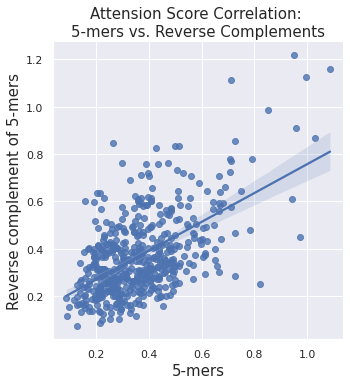

In [86]:
################################### Correlation plots for reverse complements ###################################
import seaborn as sns
import matplotlib.pyplot

i=0
five_mers = {}
for k in ordered_map.items():
    if k[0] in tb.keys(): #k[0] is not a reverse complement

        r = reverse_complement(k[0])
#         print(f"r {r}")
#         print(f"k[0] {k[0]}")
        values = [ordered_map[k[0]], ordered_map[r]] #first is 5mer, second is reverse complement value
        five_mers[k[0]] = values
corr = pd.DataFrame.from_dict(five_mers,orient='index', columns=['five_mer', 'reverse_comp'])

# df = pd.DataFrame(list(five_mers.items()),columns = ['Sequence','five_mers','reverse_comp'])
# df['reverse_comp'] = reverse_complement.value()
# sns.scatterplot(x=five_mers, y=reverse_comp, data=con);
# print(five_mers.keys())
# print(reverse_comp.keys())
# five_mers
# ax = sns.scatterplot(x="five_mer", y="reverse_comp", data=corr)
sns.set_theme(style="darkgrid")

sns.lmplot(x="five_mer", y="reverse_comp",data=corr);
plt.title("Attension Score Correlation: \n5-mers vs. Reverse Complements", fontsize=15)
plt.xlabel("5-mers", fontsize=15);
plt.ylabel("Reverse complement of 5-mers", fontsize=15);

######### ADD X ticks!!!#########
# seqs = []
# rseqs = []
# i = 0
# for k in ordered_map.items():
#     if i %20 ==0:
#         seqs.append(k[0])
#         rseqs.append(reverse_complement(k[0]))
#     i+= 1
# #         r = reverse_complement(k[0])
# print(seqs)
# x = range(0,len(seqs))
# print(x)


# Add person correlation annotation
from scipy import stats
num = stats.pearsonr(corr['five_mer'], corr['reverse_comp'])[0]
text = "Pearson Correlation = " + f'{num:.5f}'

plt.text(0, 110, text, horizontalalignment='left', size='medium', color='black', weight='semibold')


In [ ]:
ordered_map.keys()

## 1.2 Add reverse complement scores to 5mer scores

In [84]:
# if you are using batches the outputs will be in batches
# get exact attentions of chars
from IPython.display import display
mapped_add = {}
## Lots of sequences seq=1:151
for seq in range(len(attention_outputs)):
# for seq in range(1,5):
    
    # tokens are the 5mers in the current sequence
    tokens = tokenize(ReverseOneHotEncode(d[seq]))
    # for 147bp each sequence, there are 320 feature scores for each bp

    #     for i in range(len(attention_outputs[0])):
    for i in range(len(tokens)):
        token = tokens[i]
        five_mer_attention_output = sum(attention_outputs[seq][i])
        if token in mapped_add.keys():  # if a 5mer is found
            mapped_add[token] = mapped_add[token] + five_mer_attention_output #increase value
            mapped_add[reverse_complement(token)] = mapped_add[token] #set the reverse compliement value to the same
            
        elif reverse_complement(token) in mapped_add.keys():# if a 5mer's reverse complement is found
            mapped_add[reverse_complement(token)] = mapped_add[reverse_complement(token)] + five_mer_attention_output
            mapped_add[token] = mapped_add[reverse_complement(token)] #set the original 5mer value to the same
        else: #if 5mer not seen yet
            mapped_add[token] = five_mer_attention_output
            mapped_add[reverse_complement(token)] = mapped_add[token]
#     char_df = plot_attention_from_seq(tokens, mapped[token])
#     display(char_df)

# Plot the mapped dictionary for each 5 mer
# Darker means higher attention score
# import collections
# ordered_map_add = collections.OrderedDict(sorted(mapped_add.items()))
# char_df = plot_attention_from_map(mapped_add)
# display(char_df)
# char_df = plot_attention_from_map(ordered_map_add)
# display(char_df)

In [85]:
# print(ordered_kmerCounts.keys())
for k, _ in mapped_add.items():
    r = reverse_complement(k)
    v = mapped_add[k] / (kmerCounts[k] + kmerCounts[r])
    mapped_add[k] = v

In [ ]:
mapped

In [87]:
mapped['CCCCC']

0.20768829807003628

In [88]:
mapped['CGCGC']

0.36346814949630607

In [89]:
mapped['ATATA']

1.0875059892428107

In [90]:
mapped['AAAAA']

0.29805556211448275

## 3. Plot correlation for attention scores and DNA shape

In [92]:
################################### Correlation plots for DNA shape ###################################
import seaborn as sns
import matplotlib.pyplot

# use added reverse complement score way
attention_score = []
for k in tb.items(): # set values to the 5mer order as seen in tb
    attention_score.append(mapped_add[k[0]]) 
    
shape_df =  pd.DataFrame.from_dict(tb,orient='index', columns=['Shear', 'Stretch', 'Stagger', 'Buckle', 'Propel', 'Opening', 
'Shift_-1', 'Shift_1', 'Slide_-1', 'Slide_1', 'Rise_-1', 'Rise_1','Tilt_-1', 'Tilt_1', 
'Roll_-1', 'Roll_1', 'Twist_-1', 'Twist_1', 'mingw', 'mingd', 'majgw', 'majgd', 
'Shear-SD', 'Stretch-SD', 'Stagger-SD', 'Buckle-SD', 'Propel-SD', 'Opening-SD', 
'Shift-SD', 'Slide-SD', 'Rise-SD', 'Tilt-SD', 'Roll-SD', 'Twist-SD', 'mingw-SD', 
'mingd-SD', 'majgw-SD', 'majgd-SD'])
# print(shape_df)
shape_df['attention_score'] = attention_score
# print(shape_df)
# sns.set_theme(style="darkgrid")

# sns.pairplot(shape_df);
# plt.title("Attension Score Correlation: \n5-mers vs. Reverse Complements", fontsize=15)
# plt.xlabel("5-mers", fontsize=15);
# plt.ylabel("Reverse complement of 5-mers", fontsize=15);

# ######### ADD X ticks!!!#########
# seqs = []
# rseqs = []
# i = 0
# for k in ordered_map.items():
#     if i %20 ==0:
#         seqs.append(k[0])
#         rseqs.append(reverse_complement(k[0]))
#     i+= 1
# #         r = reverse_complement(k[0])
# print(seqs)
# x = range(0,len(seqs))
# print(x)

#################### Add person correlation annotation ###################
# from scipy import stats
# num = stats.pearsonr(corr['five_mer'], corr['reverse_comp'])[0]**2
# text = "$R^2$ = " + f'{num:.5f}'

# plt.text(80, 110, text, horizontalalignment='left', size='medium', color='black', weight='semibold')


In [ ]:
ordered_map_add['TTCAA']-20.638285910197766 # sanity check orders are correct

In [ ]:
#################### Add person correlation annotation ###################
from scipy import stats
AllDNAshape = ['Shear', 'Stretch', 'Stagger', 'Buckle', 'Propel', 'Opening', 
'Shift_-1', 'Shift_1', 'Slide_-1', 'Slide_1', 'Rise_-1', 'Rise_1',
            'Tilt_-1', 'Tilt_1', 
'Roll_-1', 'Roll_1', 'Twist_-1', 'Twist_1', 'mingw', 'mingd', 'majgw', 'majgd', 
'Shear-SD', 'Stretch-SD', 'Stagger-SD', 'Buckle-SD', 'Propel-SD', 'Opening-SD', 
'Shift-SD', 'Slide-SD', 'Rise-SD', 'Tilt-SD', 'Roll-SD', 'Twist-SD', 'mingw-SD', 
'mingd-SD', 'majgw-SD', 'majgd-SD']
pearson=[]
p_val=[]
for shape in AllDNAshape:
    cor = stats.pearsonr(shape_df[shape], shape_df['attention_score'])[0]
    pval = stats.pearsonr(shape_df[shape], shape_df['attention_score'])[0]
    r2 = stats.pearsonr(shape_df[shape], shape_df['attention_score'])[0]**2
    pearson.append(cor)
    p_val.append(pval)
#     num=1
    print(f"{shape} vs. attention_score | Pearson: {cor:.5f}, P-value {pval:.5f} | R^2: {r2:.5f}")
pearson

In [ ]:
idx = pearson.index(max(pearson))
s = AllDNAshape[idx]
m = max(pearson)
print(idx)
p = p_val[idx]
print(f"Most correlated shape is {s} with Pearson: {m:.5f}, P-value {p:.5f}") 